In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("/content/house prediction.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning
0,13300000,7420,4,2,3,yes,no,no,no,yes
1,12250000,8960,4,4,4,yes,no,no,no,yes
2,12250000,9960,3,2,2,yes,no,yes,no,no
3,12215000,7500,4,2,2,yes,no,yes,no,yes
4,11410000,7420,4,1,2,yes,yes,yes,no,yes


In [ ]:
# checking for missing value
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   price            545 non-null    int64 
 1   area             545 non-null    int64 
 2   bedrooms         545 non-null    int64 
 3   bathrooms        545 non-null    int64 
 4   stories          545 non-null    int64 
 5   mainroad         545 non-null    object
 6   guestroom        545 non-null    object
 7   basement         545 non-null    object
 8   hotwaterheating  545 non-null    object
 9   airconditioning  545 non-null    object
dtypes: int64(5), object(5)
memory usage: 42.7+ KB


In [ ]:
# summary statistics
df.describe()

,price,area,bedrooms,bathrooms,stories
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['mainroad']= le.fit_transform(df['mainroad'])
df['guestroom']= le.fit_transform(df['guestroom'])
df['basement']= le.fit_transform(df['basement'])
df['hotwaterheating']= le.fit_transform(df['hotwaterheating'])
df['airconditioning']=le.fit_transform(df['airconditioning'])

# yes ---> 1
# no ---->0

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning
0,13300000,7420,4,2,3,1,0,0,0,1
1,12250000,8960,4,4,4,1,0,0,0,1
2,12250000,9960,3,2,2,1,0,1,0,0
3,12215000,7500,4,2,2,1,0,1,0,1
4,11410000,7420,4,1,2,1,1,1,0,1


In [ ]:
X =df.drop("price",axis=1)
y= df['price']

print(X.head())
print(y.head())

   area  bedrooms  bathrooms  stories  mainroad  guestroom  basement  \
0  7420         4          2        3         1          0         0   
1  8960         4          4        4         1          0         0   
2  9960         3          2        2         1          0         1   
3  7500         4          2        2         1          0         1   
4  7420         4          1        2         1          1         1   

   hotwaterheating  airconditioning  
0                0                1  
1                0                1  
2                0                0  
3                0                1  
4                0                1  
0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64


In [ ]:
# train-test-split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

# print(X_train)
print("shape of X-train",X_train.shape)
print("shape of X-test",X_test.shape)
print("shape of y-train",y_train.shape)
print("shape of y-train",y_train.shape)

shape of X-train (436, 9)
shape of X-test (109, 9)
shape of y-train (436,)
shape of y-train (436,)


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled= scaler.fit_transform(X_test)

# print(X_train_scaled)
# print(X_test_scaled)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)


In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(np.round(mse,2))
r2_score= r2_score(y_test,y_pred)


print("mae:",mae)
print("mse:",mse)
print("rmse:",rmse)
print("r2_score:",r2_score)

mae: 1022734.9262196037
mse: 2044463084911.8103
rmse: 1429847.2243256655
r2_score: 0.5955218771795251


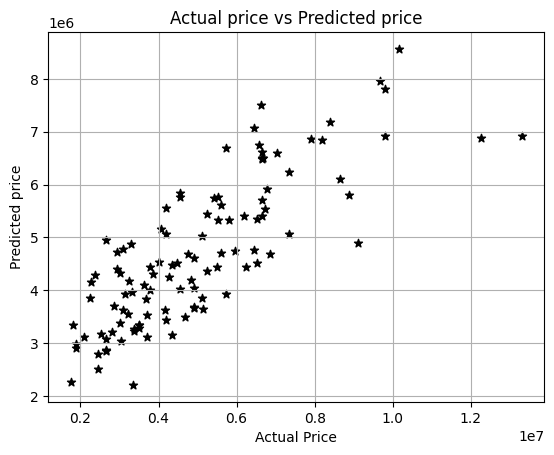

In [ ]:
# visualization

plt.scatter(y_test,y_pred,color="black",marker="*")
plt.xlabel("Actual Price")
plt.ylabel("Predicted price")
plt.title("Actual price vs Predicted price")
plt.grid(True)
plt.show()

In [ ]:
# user prediction

area = float(input("enter area:"))

bedrooms= float(input("enter number of bedrooms:"))

bathrooms= float(input("enter number bathroom:"))

stories = float(input("enter number of stories:"))

guestroom= int(input("yo want guestroom (Answer 1--> yes and 0-->No)"))

mainroad = int(input("you want mainroad(Answer 1--> yes and 0-->no)"))

basement = int(input("yo want basement(Answer 1--> yes and 0-->No)"))

hotwaterheating= int(input("yo want hotwaterheating (Answer 1--> yes and 0-->No)"))

airconditioning = int(input("yo want aircondtioning (Answer 1--> yes and 0-->No)"))

values = [area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning]

user_input= pd.DataFrame([values],columns=X.columns)


user_input_scaled = scaler.transform(user_input)
predicted_price = model.predict(user_input_scaled)

print("------Your House Predicted Price is -----")
print(predicted_price)

enter area:7200
enter number of bedrooms:2
enter number bathroom:2
enter number of stories:1
yo want guestroom (Answer 1--> yes and 0-->No)1
you want mainroad(Answer 1--> yes and 0-->no)1
yo want basement(Answer 1--> yes and 0-->No)1
yo want hotwaterheating (Answer 1--> yes and 0-->No)0
yo want aircondtioning (Answer 1--> yes and 0-->No)0
------Your House Predicted Price is -----
[5792624.88001608]
